<a href="https://www.kaggle.com/code/lalit7881/developer-salary-predictor-dataset?scriptVersionId=304167714" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/data_dictionary.csv
/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/train.csv
/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/test.csv


## Loading dataset

In [2]:
# File paths
data_dict_path = "/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/data_dictionary.csv"
train_path = "/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/train.csv"
test_path = "/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/test.csv"

# Load data
data_dict = pd.read_csv(data_dict_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [3]:
# Shape
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

# Preview
train_df.head()

Train Shape: (40000, 7)
Test Shape: (10000, 7)


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29,USA,Masters,"C++, Ruby","Spring, Angular",11-50,214386
4,7,USA,Bachelors,"C#, Rust","React, Express",1-10,107584


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   experience    40000 non-null  int64 
 1   country       40000 non-null  object
 2   education     40000 non-null  object
 3   languages     40000 non-null  object
 4   frameworks    40000 non-null  object
 5   company_size  40000 non-null  object
 6   salary_usd    40000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


In [5]:
train_df.describe()

,experience,salary_usd
count,40000.000000,40000.000000
mean,19.912875,131834.441525
std,11.865220,46426.249810
min,0.000000,12024.000000
25%,10.000000,98172.250000
50%,20.000000,130579.000000
75%,30.000000,164431.000000
max,40.000000,277554.000000


In [6]:
train_df.isnull().sum()

experience      0
country         0
education       0
languages       0
frameworks      0
company_size    0
salary_usd      0
dtype: int64

In [7]:
train_df.columns

Index(['experience', 'country', 'education', 'languages', 'frameworks',
       'company_size', 'salary_usd'],
      dtype='object')

In [8]:
for col in train_df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(train_df[col].value_counts())


country:
country
USA          16003
UK            4013
Canada        4003
Germany       3988
India         3970
Australia     2064
France        2031
Japan         1918
Brazil        1030
Singapore      980
Name: count, dtype: int64

education:
education
Bachelors       20061
Masters         11968
Some College     4005
High School      1988
PhD              1978
Name: count, dtype: int64

languages:
languages
Swift, Python             458
JavaScript, JavaScript    450
Java, Python              443
Swift, PHP                434
Go, Python                432
                         ... 
C++, Swift                367
Rust, C++                 363
Ruby, Ruby                360
C#, Swift                 357
JavaScript, Java          352
Name: count, Length: 100, dtype: int64

frameworks:
frameworks
Flask, ASP.NET            446
Ruby on Rails, Angular    441
React, Express            440
ASP.NET, React            440
Angular, Flask            437
                         ... 
Vue, React   

In [9]:
data_dict.head()

,Column,Type,Description
0,experience,number,Years of professional coding experience
1,country,string,Country of residence
2,education,string,Highest level of formal education
3,languages,string,Primary programming languages
4,frameworks,string,Primary frameworks used


In [10]:
# Fill missing values
train_df.fillna(method='ffill', inplace=True)

# Remove duplicates
train_df.drop_duplicates(inplace=True)

In [11]:
train_df.info()
print("\nMissing values per column:\n", train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   experience    40000 non-null  int64 
 1   country       40000 non-null  object
 2   education     40000 non-null  object
 3   languages     40000 non-null  object
 4   frameworks    40000 non-null  object
 5   company_size  40000 non-null  object
 6   salary_usd    40000 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB

Missing values per column:
 experience      0
country         0
education       0
languages       0
frameworks      0
company_size    0
salary_usd      0
dtype: int64


## EDA

In [12]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

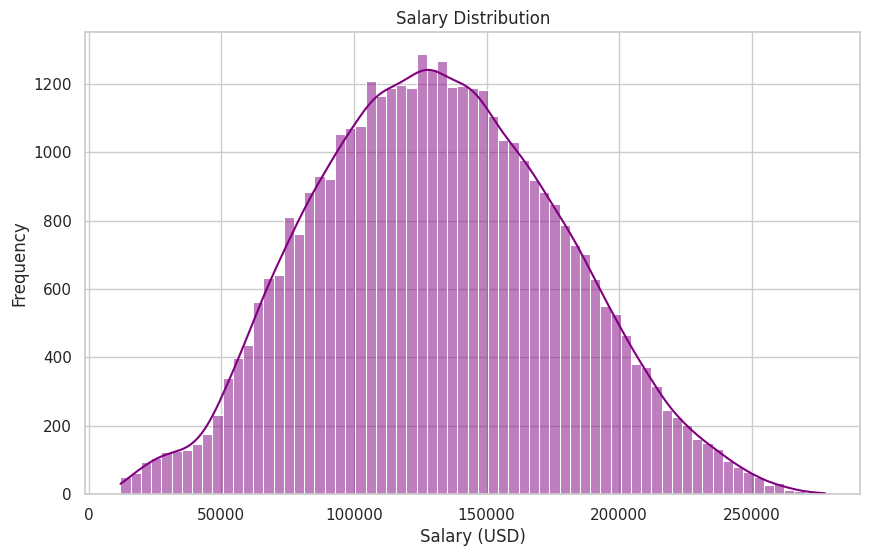

In [13]:
sns.histplot(train_df['salary_usd'], kde=True, color='purple')
plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")
plt.show()

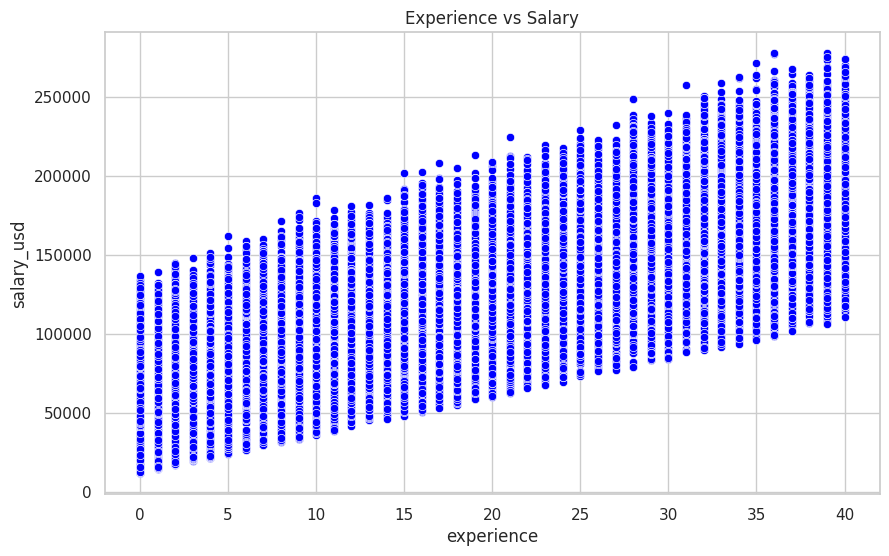

In [14]:
sns.scatterplot(x='experience', y='salary_usd', data=train_df, color='blue')
plt.title("Experience vs Salary")
plt.show()

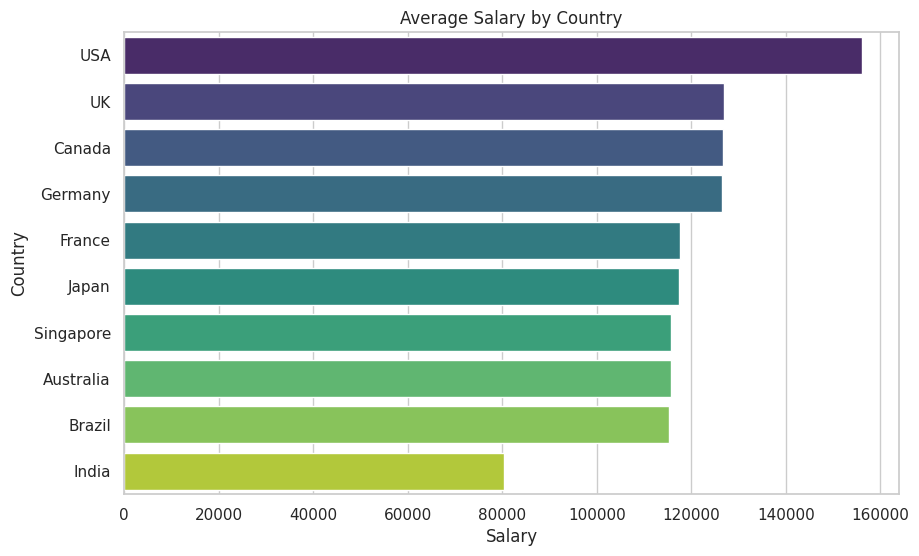

In [15]:
country_salary = train_df.groupby('country')['salary_usd'].mean().sort_values(ascending=False)

sns.barplot(x=country_salary.values, y=country_salary.index, palette='viridis')
plt.title("Average Salary by Country")
plt.xlabel("Salary")
plt.ylabel("Country")
plt.show()

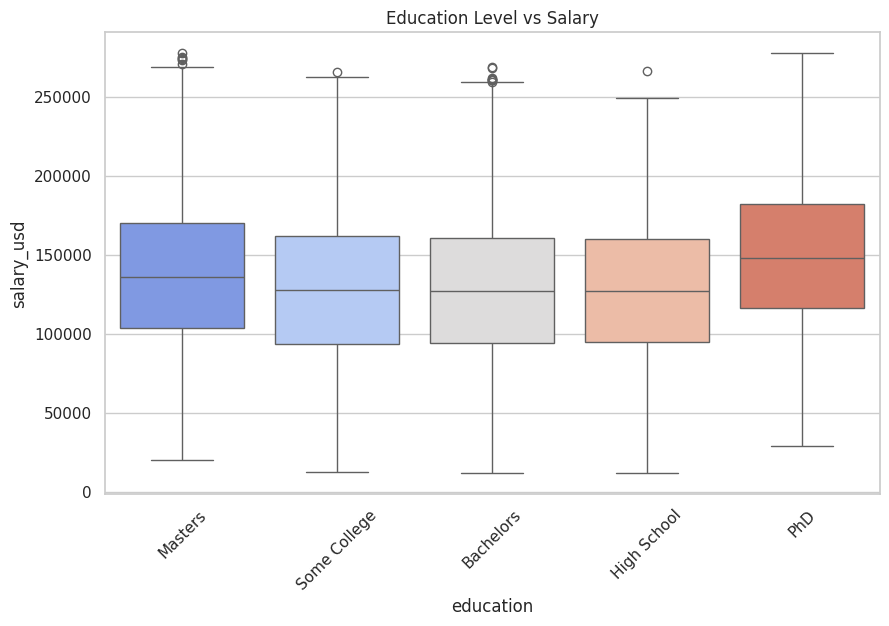

In [16]:
sns.boxplot(x='education', y='salary_usd', data=train_df, palette='coolwarm')
plt.title("Education Level vs Salary")
plt.xticks(rotation=45)
plt.show()

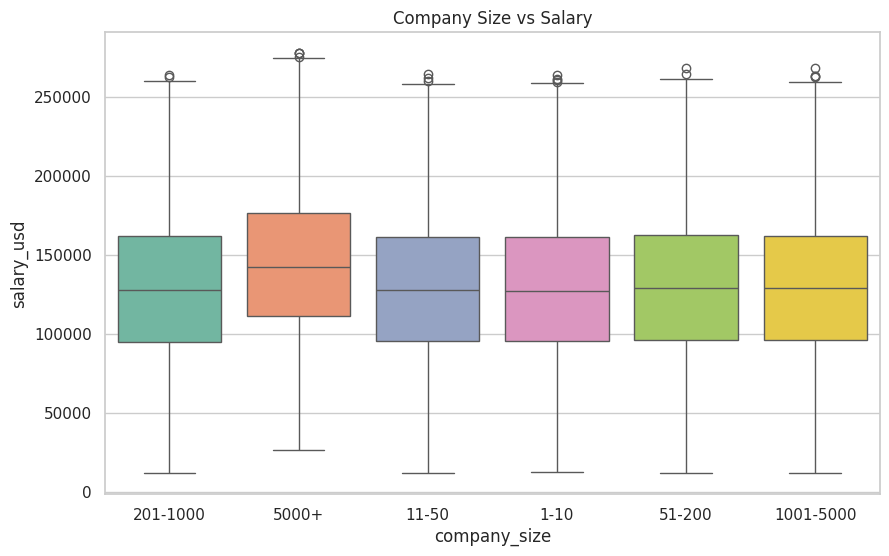

In [17]:
sns.boxplot(x='company_size', y='salary_usd', data=train_df, palette='Set2')
plt.title("Company Size vs Salary")
plt.show()

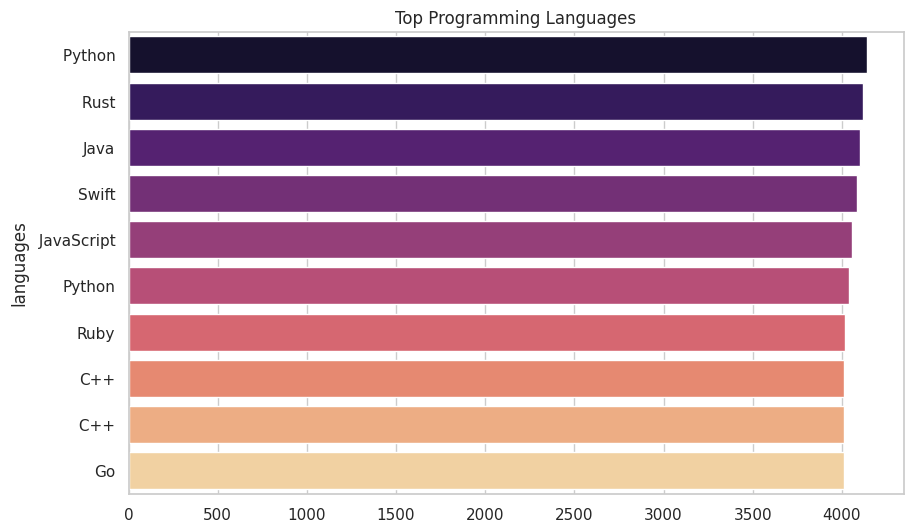

In [18]:
# Split languages column (if multiple values separated by comma)
lang_series = train_df['languages'].dropna().str.split(',').explode()

top_langs = lang_series.value_counts().head(10)

sns.barplot(x=top_langs.values, y=top_langs.index, palette='magma')
plt.title("Top Programming Languages")
plt.show()

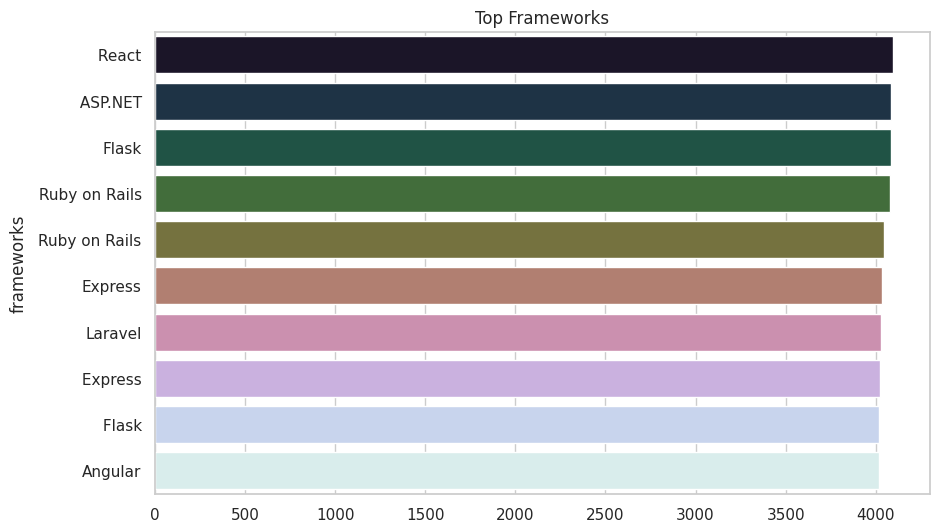

In [19]:
framework_series = train_df['frameworks'].dropna().str.split(',').explode()

top_frameworks = framework_series.value_counts().head(10)

sns.barplot(x=top_frameworks.values, y=top_frameworks.index, palette='cubehelix')
plt.title("Top Frameworks")
plt.show()

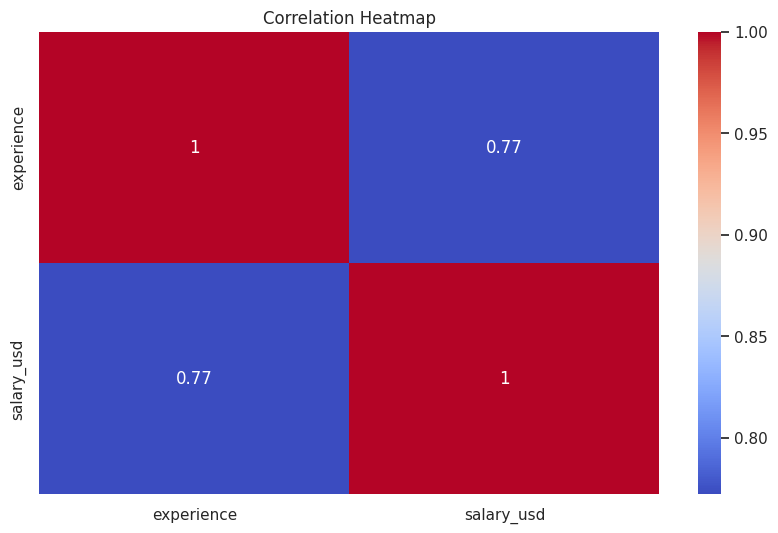

In [20]:
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

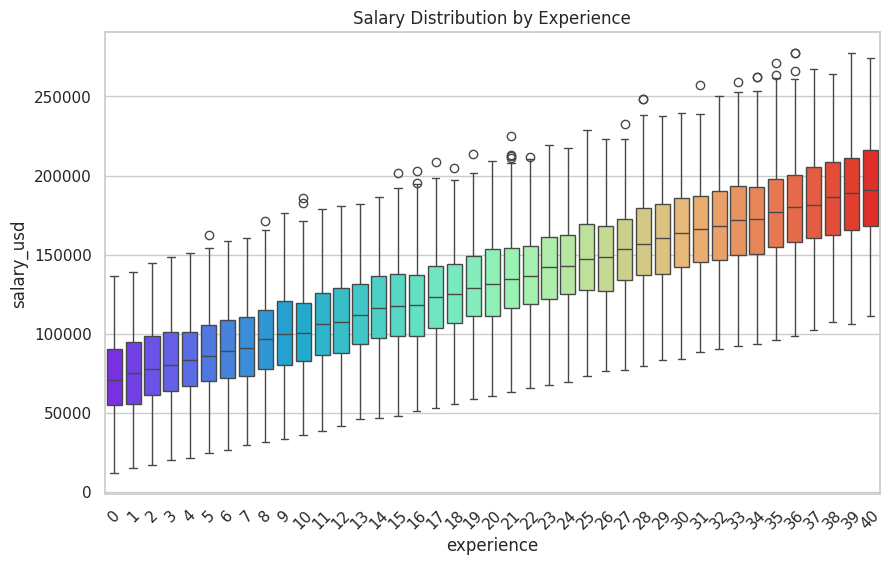

In [21]:
sns.boxplot(x='experience', y='salary_usd', data=train_df, palette='rainbow')
plt.title("Salary Distribution by Experience")
plt.xticks(rotation=45)
plt.show()

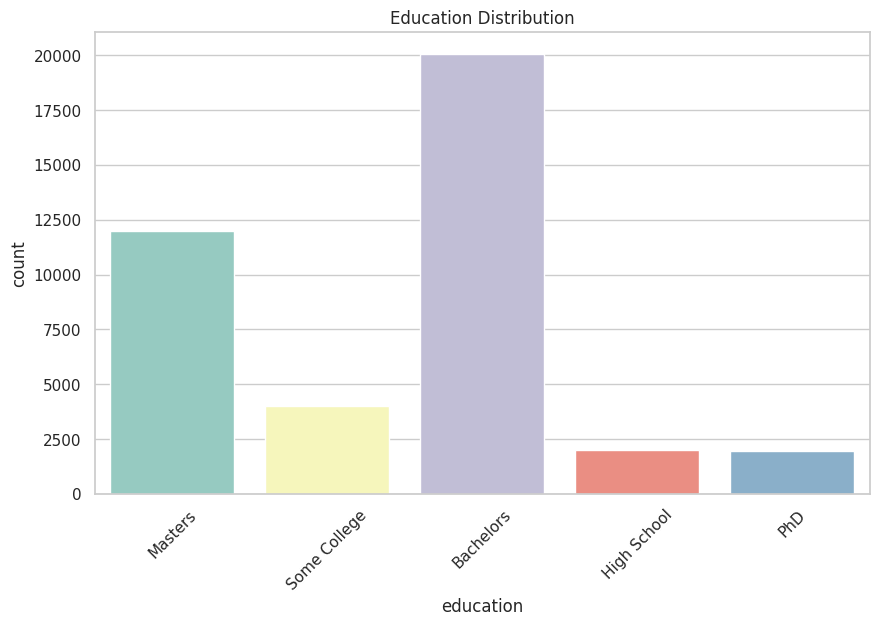

In [22]:
sns.countplot(x='education', data=train_df, palette='Set3')
plt.title("Education Distribution")
plt.xticks(rotation=45)
plt.show()

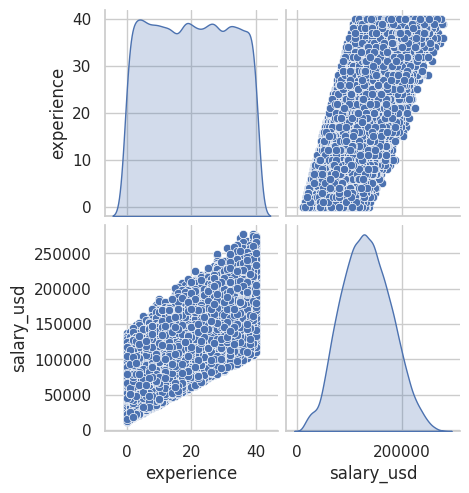

In [23]:
# Pairplot (small datasets only)
sns.pairplot(train_df, diag_kind='kde')
plt.show()

## Feature engineering

In [24]:
from sklearn.preprocessing import LabelEncoder

train = train_df.copy()  # ✅ FIX: use train_df

cat_cols = ["country", "education", "languages", "frameworks", "company_size"]

for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))

print("Encoding done")

Encoding done


In [25]:
from sklearn.model_selection import train_test_split

X = train.drop("salary_usd", axis=1)
y = train["salary_usd"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Split done")

Split done


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    
    results.append([name, rmse, r2])
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2 Score"])
results_df


Linear Regression
RMSE: 25316.579232724136
R2 Score: 0.70228326886616

Decision Tree
RMSE: 23364.506716108142
R2 Score: 0.7464250038850979

Random Forest
RMSE: 17418.17120625503
R2 Score: 0.8590716702870436


,Model,RMSE,R2 Score
0,Linear Regression,25316.579233,0.702283
1,Decision Tree,23364.506716,0.746425
2,Random Forest,17418.171206,0.859072


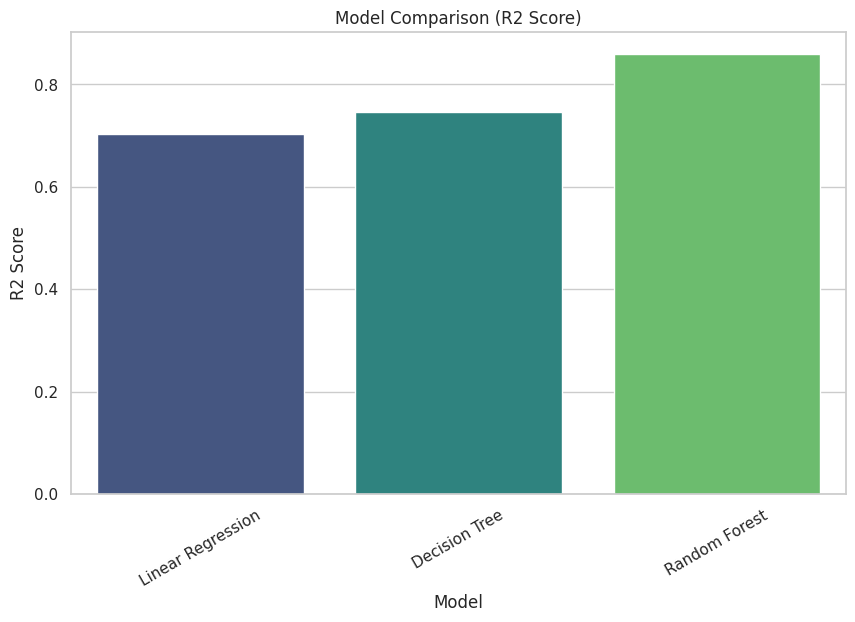

In [27]:
sns.barplot(x="Model", y="R2 Score", data=results_df, palette="viridis")
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=30)
plt.show()

## Thank you..pls upvote!!!!!